# <b><font color='teal'>Homework 22</font></b>

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	classification_report,
	precision_recall_curve,
)


1. Обучите модель логистической регрессии на наборе данных Breast Cancer. Оцените модель с помощью показателей точности, precision, recall и F1-score. Постройте кривую Precision-Recall.

In [2]:
# В переменную df_breast_cancer запишите датасет BreastCancer
breast_cancer = load_breast_cancer(as_frame=True)
df_breast_cancer = breast_cancer.frame
display(df_breast_cancer)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
# В переменную X запишите все данные из компонента data датасета
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
X = breast_cancer.data


In [4]:
# В переменную y запишите компонент target датасета
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
y = breast_cancer.target


In [5]:
# В переменные X_train, X_test, y_train, y_test запишите обучающие и тестовые данные
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
# Инициализируйте модель логистической регрессии в переменную model_log_regr
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
model_log_regr = LogisticRegression(max_iter=5000, random_state=42)


In [7]:
# Обучите модель на обучающих данных
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
model_log_regr.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [8]:
# Сделайте прогнозы для тестового набора в переменные y_pred_log_regr
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
y_pred_log_regr = model_log_regr.predict(X_test)


In [9]:
# В переменную y_scores_log_regr запишите результат работы функции predict_proba
# (Синтаксис в файле "Метрики оценки модели" - п.2 - Precision-Recall)
y_scores_log_regr = model_log_regr.predict_proba(X_test)[:, 1]


In [10]:
# Выведите отчет о классификации и сделайте вывод о точности модели на основе метрик precision, recall, F1-score
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
accuracy_log_regr = accuracy_score(y_test, y_pred_log_regr)
precision_log_regr = precision_score(y_test, y_pred_log_regr)
recall_log_regr = recall_score(y_test, y_pred_log_regr)
f1_log_regr = f1_score(y_test, y_pred_log_regr)

print("Accuracy:", accuracy_log_regr)
print("Precision:", precision_log_regr)
print("Recall:", recall_log_regr)
print("F1-score:", f1_log_regr)
print()
print(classification_report(y_test, y_pred_log_regr))
print("Модель логистической регрессии показывает хорошие значения метрик precision, recall и F1-score на тестовой выборке.")


Accuracy: 0.9649122807017544
Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1-score: 0.9726027397260274

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Модель логистической регрессии показывает хорошие значения метрик precision, recall и F1-score на тестовой выборке.


In [11]:
# Рассчитайте кривую Precision-Recall в переменные precisions_log_regr, recalls_log_regr, thresholds_log_regr
# (Синтаксис в файле "Метрики оценки модели" - п.2 - Precision-Recall)
precisions_log_regr, recalls_log_regr, thresholds_log_regr = precision_recall_curve(y_test, y_scores_log_regr)


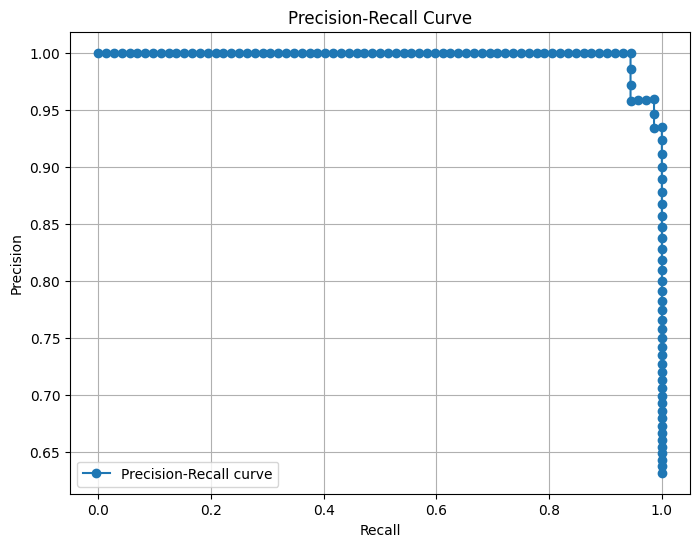

In [12]:
# Постройте график кривой Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recalls_log_regr, precisions_log_regr, label='Precision-Recall curve', marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()


2. Проведите кросс-валидацию с использованием набора данных banknote_authentication.csv и модели логистической регрессии. Оцените модель с помощью оценок кросс-валидации и постройте кривую обучения.

In [31]:
# Загрузите данные в датафрейм df_banknote
banknote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
df_banknote = pd.read_csv(banknote_url, header=None, names=['A', 'B', 'C', 'D', 'target'])
display(df_banknote)


,A,B,C,D,target
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [14]:
# В переменную X запишите столбцы A, B, C, D
X = df_banknote[['A', 'B', 'C', 'D']]


In [15]:
# В переменную y запишите столбец target
y = df_banknote['target']


In [16]:
# Инициализируйте модель логистической регрессии в переменную model
model = LogisticRegression(random_state=42)


In [17]:
# Выполните перекрестную валидацию в переменную cv_scores
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')


In [18]:
# Выведите оценки кросс-валидации
print('Оценки кросс-валидации:', cv_scores)
print('Средняя accuracy:', cv_scores.mean())
print('Стандартное отклонение:', cv_scores.std())


Оценки кросс-валидации: [0.98909091 0.98909091 0.98175182 1.         0.98905109]
Средняя accuracy: 0.9897969475779694
Стандартное отклонение: 0.005837457595207762


In [19]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
# Обучите модель на обучающих данных
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [21]:
# Сделайте предсказания на обучающем и тестовом наборах в переменные y_train_pred и y_test_pred
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [25]:
# Рассчитайте accuracy на обучающем и тестовом наборах в переменные train_accuracy и test_accuracy
# Выведите результаты на экран
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print('Train accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)


Train accuracy: 0.9927073837739289
Test accuracy: 0.9854545454545455


In [28]:
# Определите функцию для построения кривых обучения
# (Синтаксис в файле "Переобучение и недообучение" - п.1.1. - Кривые обучения)
def plot_learning_curves(estimator, X, y, train_sizes = np.linspace(0.1, 1.0, 10), cv = 5):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator, X, y, train_sizes = train_sizes, cv = cv, scoring = 'neg_mean_squared_error'
    )
    
    train_scores_mean = -train_scores.mean(axis = 1)
    validation_scores_mean = -validation_scores.mean(axis = 1)
    
    plt.figure(figsize = (12, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color = 'r', label = 'Training error')
    plt.plot(train_sizes, validation_scores_mean, 'o-', color = 'g', label = 'Validation error')
    plt.xlabel('Размер обучающих данных')
    plt.ylabel('Ошибка')
    plt.title('Кривые обучения')
    plt.legend(loc = 'best')
    plt.grid()
    plt.show()

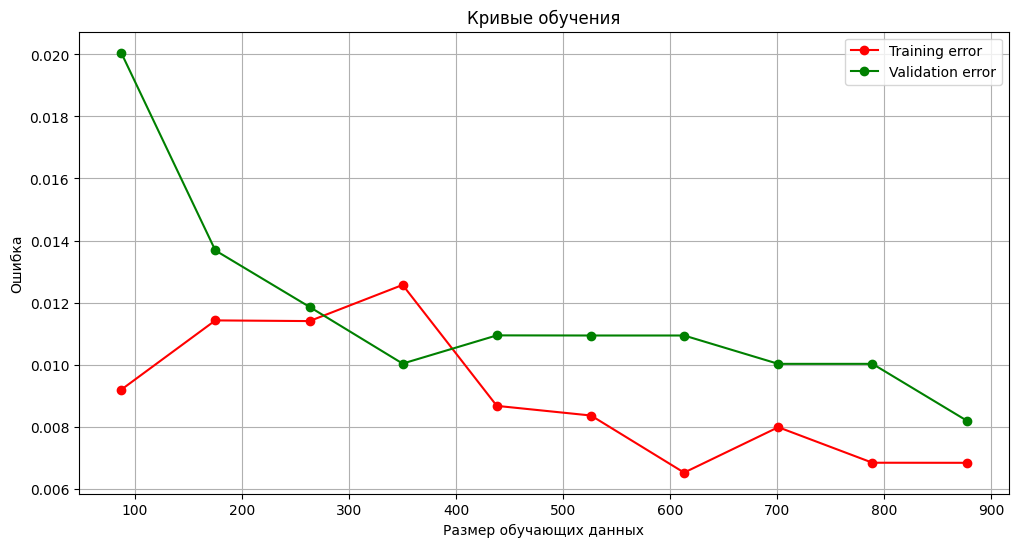

Если train error заметно ниже validation error, модель склонна к переобучению.
Если обе ошибки высокие и близкие друг к другу, это признак недообучения.


In [30]:
# Постройте кривые обучения и сделайте вывод о недообученности/переобученности модели
# (Синтаксис в файле "Переобучение и недообучение" - п.1.1. - Кривые обучения)
plot_learning_curves(model, X_train, y_train)

# Интерпретация графика
print('Если train error заметно ниже validation error, модель склонна к переобучению.')
print('Если обе ошибки высокие и близкие друг к другу, это признак недообучения.')